# Neurality: Content Diversity & Feed Mixing Engine
This notebook implements and tests our dynamic feed mixing engine designed to prevent filter bubbles and repetitive feeds.

### Target Mix Proportions:
- **Session-Interest Collaborative Feed**: 50%
- **Trending Feed**: 20%
- **Following Feed**: 20%
- **Random Explore Feed**: 10%

In [1]:
# ==================================================
# NOTEBOOK VALIDATION & DEPENDENCY VERIFICATION PIPELINE
# ==================================================
import sys
import time
import numpy as np
import pandas as pd
import scipy
import sklearn
import matplotlib
import seaborn as sns
import torch

print(f"[SUCCESS] Jupyter Kernel Python Version: {sys.version}")
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"scipy: {scipy.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"seaborn: {sns.__version__}")
print(f"torch: {torch.__version__}")
print("[HEALTH CHECK] Conda kernel detection and package imports are 100% stable!")


[SUCCESS] Jupyter Kernel Python Version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
numpy: 2.1.3
pandas: 2.2.3
scipy: 1.15.3
scikit-learn: 1.6.1
matplotlib: 3.10.0
seaborn: 0.13.2
torch: 2.10.0+cpu
[HEALTH CHECK] Conda kernel detection and package imports are 100% stable!


In [2]:
# Mock Candidate Generation
np.random.seed(1337)
n_candidates = 300

# Generate 300 candidate reels
creators = [f"creator_{i}" for i in range(1, 40)]
tags_pool = ['phonk', 'dark', 'edits', 'gaming', 'tech', 'anime', 'memes', 'cooking', 'crypto', 'cringe']

candidates = []
for idx in range(1, n_candidates + 1):
    creator = np.random.choice(creators)
    tags = list(np.random.choice(tags_pool, size=np.random.randint(1, 4), replace=False))
    score_collaborative = np.random.uniform(0.1, 1.0)
    score_trending = np.random.uniform(0.1, 1.0)
    is_following = np.random.choice([True, False], p=[0.1, 0.9])
    
    candidates.append({
        'id': idx,
        'creator': creator,
        'tags': tags,
        'score_collaborative': score_collaborative,
        'score_trending': score_trending,
        'is_following': is_following
    })

print(f"Generated {n_candidates} candidates available for feed construction.")

Generated 300 candidates available for feed construction.


In [4]:
# Dynamic Feed Mixing Engine Implementation
def generate_mixed_feed(candidates, limit=10, mix_ratio=(0.50, 0.20, 0.20, 0.10)):
    """
    Mixes candidates into a unified feed based on mix_ratio:
    (Session/Collab %, Trending %, Following %, Random %)
    """
    n_collab = int(round(limit * mix_ratio[0]))
    n_trending = int(round(limit * mix_ratio[1]))
    n_following = int(round(limit * mix_ratio[2]))
    n_random = limit - (n_collab + n_trending + n_following)

    # 1. Collaborative / Session Intent Feed Candidates
    collab_candidates = sorted(candidates, key=lambda x: x['score_collaborative'], reverse=True)
    
    # 2. Trending Candidates
    trending_candidates = sorted(candidates, key=lambda x: x['score_trending'], reverse=True)
    
    # 3. Following Candidates
    following_candidates = [c for c in candidates if c['is_following']]
    # Fallback to collaborative if following count is insufficient
    if len(following_candidates) < n_following:
        following_candidates = collab_candidates
    else:
        following_candidates = sorted(following_candidates, key=lambda x: x['score_collaborative'], reverse=True)
        
    # 4. Random / Explore Candidates
    import random
    explore_candidates = list(candidates)
    random.shuffle(explore_candidates)

    feed = []
    seen_ids = set()

    def add_from_list(cand_list, count, label):
        added = 0
        for c in cand_list:
            if c['id'] not in seen_ids:
                seen_ids.add(c['id'])
                c_copy = dict(c)
                c_copy['source_feed'] = label
                feed.append(c_copy)
                added += 1
                if added >= count:
                    break

    add_from_list(collab_candidates, n_collab, 'session_collab')
    add_from_list(trending_candidates, n_trending, 'trending')
    add_from_list(following_candidates, n_following, 'following')
    add_from_list(explore_candidates, n_random, 'explore_random')

    # Shuffle slightly to interleave feeds nicely
    random.shuffle(feed)
    return feed[:limit]

feed = generate_mixed_feed(candidates, limit=10)
print("Constructed mixed feed items:")
for item in feed:
    print(f"Reel ID: {item['id']:03d} | Source: {item['source_feed']:15s} | Creator: {item['creator']} | Tags: {item['tags']}")

Constructed mixed feed items:
Reel ID: 028 | Source: explore_random  | Creator: creator_23 | Tags: [np.str_('crypto')]
Reel ID: 080 | Source: trending        | Creator: creator_12 | Tags: [np.str_('tech'), np.str_('dark'), np.str_('edits')]
Reel ID: 291 | Source: trending        | Creator: creator_2 | Tags: [np.str_('memes'), np.str_('anime'), np.str_('edits')]
Reel ID: 099 | Source: following       | Creator: creator_4 | Tags: [np.str_('tech')]
Reel ID: 062 | Source: session_collab  | Creator: creator_14 | Tags: [np.str_('phonk')]
Reel ID: 115 | Source: session_collab  | Creator: creator_29 | Tags: [np.str_('dark'), np.str_('crypto')]
Reel ID: 113 | Source: session_collab  | Creator: creator_22 | Tags: [np.str_('cooking'), np.str_('crypto')]
Reel ID: 108 | Source: session_collab  | Creator: creator_14 | Tags: [np.str_('tech'), np.str_('cringe')]
Reel ID: 044 | Source: session_collab  | Creator: creator_37 | Tags: [np.str_('tech')]
Reel ID: 096 | Source: following       | Creator: crea

Mixed Feed Generation Latency: 0.414 ms


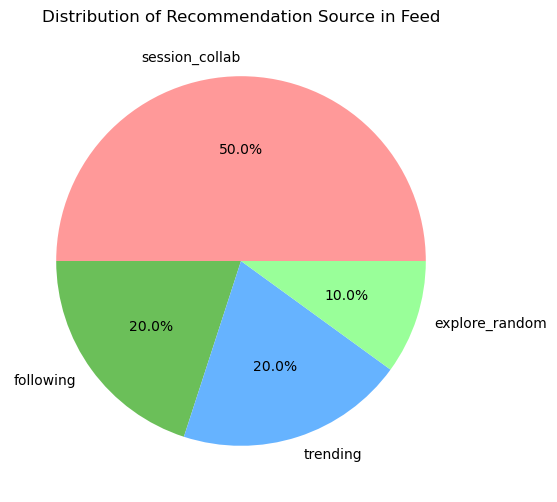

In [5]:
# Benchmark Mixed Feed Generator latency and Diversity level
import time
t0 = time.perf_counter()
for _ in range(100):
    test_feed = generate_mixed_feed(candidates, limit=20)
t1 = time.perf_counter()

feed_df = pd.DataFrame(test_feed)
source_counts = feed_df['source_feed'].value_counts(normalize=True) * 100
print(f"Mixed Feed Generation Latency: {(t1 - t0)*1000/100:.3f} ms")

import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.pie(source_counts, labels=source_counts.index, autopct='%1.1f%%', colors=['#ff9999','#6bbf59','#66b3ff','#99ff99'])
plt.title('Distribution of Recommendation Source in Feed')
plt.show()